In [31]:
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


# Carregar os dados que já preparaste
X_train = np.load("../data/X_train.npy")
y_train = np.load("../data/y_train.npy")
X_val = np.load("../data/X_val.npy")
y_val = np.load("../data/y_val.npy")
X_test = np.load("../data/X_test.npy") 
y_test = np.load("../data/y_test.npy") 

scaler_features = joblib.load('../models/scaler_features.joblib')
scaler_target = joblib.load('../models/scaler_target.joblib')

print(f"Dados carregados: {X_train.shape}")

Dados carregados: (24827, 7, 20)


In [32]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # 1. Camada de Atenção (Multi-Head Attention)
    # Aqui a IA foca-se em diferentes partes da sequência de 7 dias
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs # Conexão Residual: evita perda de sinal matemático

    # 2. Feed Forward Network (Processamento de cada dia individualmente)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res # Outra Conexão Residual

In [33]:
input_shape = (X_train.shape[1], X_train.shape[2]) # (7 dias, 10 colunas)
inputs = layers.Input(shape=input_shape)

# Aplicamos 2 blocos de Transformer para profundidade
x = transformer_encoder(inputs, head_size=256, num_heads=4, ff_dim=4, dropout=0.1)
x = transformer_encoder(x, head_size=256, num_heads=4, ff_dim=4, dropout=0.1)

# "Achatamos" a sequência para uma decisão final
x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)

# Camadas Densas (o toque final de lógica)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x) # 1 Único valor: Temp Max de amanhã

model_tf = models.Model(inputs, outputs)
model_tf.compile(optimizer="adam", loss="mse", metrics=["mae"])

model_tf.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 7, 20)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 20)     │     85,012 │ input_layer_1[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 7, 20)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 20)     │         40 │ dropout_8[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 7, 20)     │          0 │ layer_normalizat… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 7, 4)      │         84 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 7, 4)      │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 7, 20)     │        100 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 20)     │         40 │ conv1d_5[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 7, 20)     │          0 │ layer_normalizat… │
│                     │                   │            │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 20)     │     85,012 │ add_5[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 7, 20)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 20)     │         40 │ dropout_11[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 7, 20)     │          0 │ layer_normalizat… │
│                     │                   │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 7, 4)      │         84 │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 7, 4)      │          0 │ conv1d_6[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 7, 20)     │        100 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 20)     │         40 │ conv1d_7[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 7, 20)     │          0 │ layer_normalizat

 Total params: 171,961 (671.72 KB)

 Trainable params: 171,961 (671.72 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
print("A iniciar o treino do Transformer...")
history_tf = model_tf.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60, # Transformers às vezes precisam de um pouco mais de tempo
    batch_size=32,
    verbose=1
)

A iniciar o treino do Transformer...
Epoch 1/60
776/776 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0310 - mae: 0.1085 - val_loss: 0.0055 - val_mae: 0.0555
Epoch 2/60
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0067 - mae: 0.0636 - val_loss: 0.0062 - val_mae: 0.0575
Epoch 3/60
776/776 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0058 - mae: 0.0585 - val_loss: 0.0052 - val_mae: 0.0547
Epoch 4/60
776/776 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0054 - mae: 0.0564 - val_loss: 0.0052 - val_mae: 0.0540
Epoch 5/60
776/776 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0051 - mae: 0.0545 - val_loss: 0.0052 - val_mae: 0.0542
Epoch 6/60
776/776 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0048 - mae: 0.0529 - val_loss: 0.0052 - val_mae: 0.0558
Epoch 7/60
776/776 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0046 - mae: 0.0520 - val_loss: 0.0052 - val_mae: 0.0531
Epoch 8/60
776/776 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0045 - mae: 0.0516 - val_loss: 0.0049 - val_mae: 0.0537
Epoch 9/60
776/776 

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
if not os.path.exists('../models'):
    os.makedirs('../models')



y_pred_scaled = model_tf.predict(X_test)

# 2. Reverter para Celsius
y_pred = scaler_target.inverse_transform(y_pred_scaled)
y_real = scaler_target.inverse_transform(y_test)

# 3. Calcular Erro Médio (MAE)
mae_tf = mean_absolute_error(y_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_real, y_pred))
print(f"\n--- PERFORMANCE DO TRANSFORMER ---")
print(f"Erro Médio Absoluto (MAE): {mae_tf:.2f}°C")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f}°C")

# 4. Guardar o modelo
model_tf.save('../models/weather_predictor_transformer.keras')
print("Modelo guardado com sucesso em '../models/weather_predictor_transformer.keras'")

97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

--- PERFORMANCE DO TRANSFORMER ---
Erro Médio Absoluto (MAE): 2.24°C
Raiz do Erro Quadrático Médio (RMSE): 3.02°C
Modelo guardado com sucesso em '../models/weather_predictor_transformer.keras'


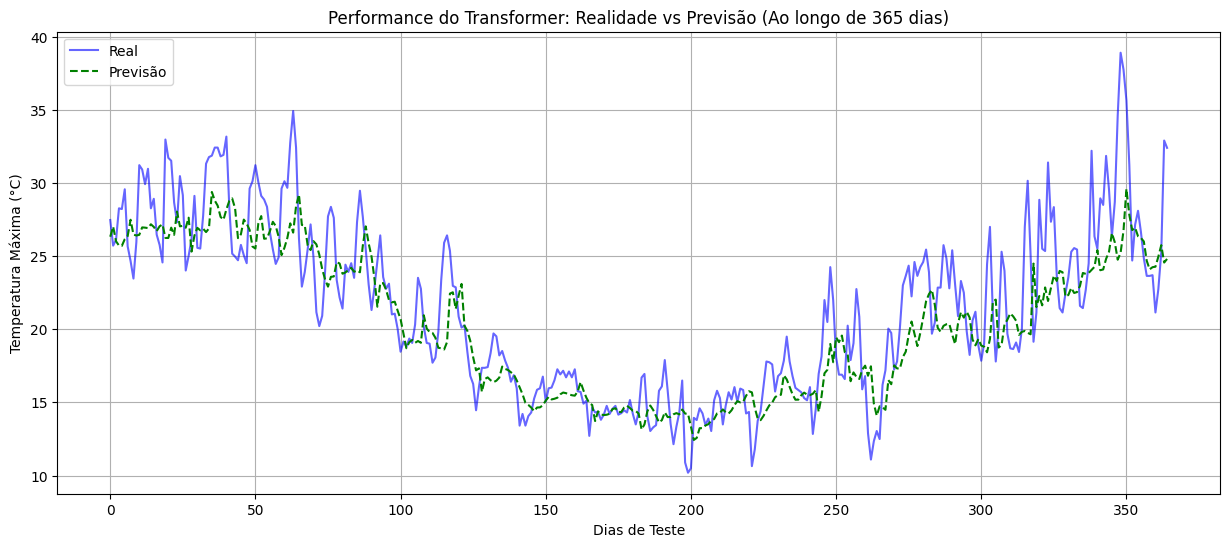

In [37]:
#Criar figura
plt.figure(figsize=(15, 6))
plt.plot(y_real[:365], label='Real', color='blue', alpha=0.6)
plt.plot(y_pred[:365], label='Previsão', color='green', linestyle='--')
plt.title('Performance do Transformer: Realidade vs Previsão (Ao longo de 365 dias)')
plt.xlabel('Dias de Teste')
plt.ylabel('Temperatura Máxima (°C)')
plt.legend()
plt.grid(True)
plt.show()